# Part 3: Can We Rescue v-Prediction?

Same setup as Part 2 but restricted to `swiss_roll`. We compare the unmodified flow-matching baseline against an **optimized** variant (`opt=True`) that injects low-rank noise aligned with the data's intrinsic 2D structure (via the random projection matrix `P`).

In [1]:
from src.model import JiM
from src.train import train_n_steps
from src.denoiser import Denoiser
from src.dataloader import get_dataloader

import torch
import torch.optim as optim

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import time
import json

In [2]:
DATASET = "swiss_roll"
DIMS = (2, 8, 32)
PRED_LOSS = (("x", "x"), ("x", "v"), ("v", "x"), ("v", "v"))

MODEL_DIR        = Path("models")                  # baseline (Part 2 weights), h=256
OPT_DIR          = Path("models/opt001")           # opt=True, h=256
OPT2_H512_DIR    = Path("models/opt002_h512")      # opt=True, h=512
OPT2_H1024_DIR   = Path("models/opt002_h1024")     # opt=True, h=1024
PART3_RESULTS    = Path("models/part3")            # aggregated results / plots-from-cache
FIG_DIR          = Path("res/part3")
for d in (MODEL_DIR, OPT_DIR, OPT2_H512_DIR, OPT2_H1024_DIR, PART3_RESULTS, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Stage registry — one entry per (training run). Used by every aggregation/plot cell below,
# so adding a new width or a new opt variant only requires appending here.
STAGES = [
    # (label,           model_dir,        hidden_dim, opt)
    ("baseline",        MODEL_DIR,        256,        False),
    ("opt001",          OPT_DIR,          256,        True),
    ("opt002_h512",     OPT2_H512_DIR,    512,        True),
    ("opt002_h1024",    OPT2_H1024_DIR,   1024,       True),
]

TRAIN_STEPS = 25000
STEPS = 50
BATCH = 1024
N_GEN = 2048

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Helpers

In [ ]:
def model_tag(dataset, D, pred, loss):
    return f"{dataset}_D{D}_{pred}pred_{loss}loss"


def train_one_config(dataset, D, pred, loss, device, model_dir, opt,
                     hidden_dim=256, n_steps=TRAIN_STEPS):
    """Train one config; persist weights + loss curve + metadata so we never have to
    rerun just to recover loss/perf numbers."""
    model_dir.mkdir(parents=True, exist_ok=True)
    dataloader = get_dataloader(name=dataset, dim=D, batch_size=BATCH)
    model = JiM(hidden_dim=hidden_dim, D=D).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    t0 = time.perf_counter()
    losses = train_n_steps(model, dataloader, optimizer, device, n_steps, pred, loss, opt=opt)
    elapsed = time.perf_counter() - t0

    tag = model_tag(dataset, D, pred, loss)
    pt_path     = model_dir / f"{tag}.pt"
    losses_path = model_dir / f"{tag}_losses.npy"
    meta_path   = model_dir / f"{tag}_meta.json"

    torch.save(model.state_dict(), pt_path)
    np.save(losses_path, np.asarray(losses, dtype=np.float32))
    meta_path.write_text(json.dumps({
        "hidden_dim": hidden_dim, "D": D, "pred": pred, "loss": loss,
        "opt": opt, "n_steps": n_steps,
        "train_time_s": elapsed,
        "n_params": sum(p.numel() for p in model.parameters()),
        "file_size_bytes": pt_path.stat().st_size,
    }, indent=2))
    return model


def generate_samples(model, D, pred_type, device, opt=False, P=None, n=N_GEN):
    denoiser = Denoiser(model, steps=STEPS, D=D)
    return denoiser.generate(n, pred_type, device, P=P, opt=opt).cpu().numpy()


def get_ground_truth(dataset, D, n=N_GEN):
    loader = get_dataloader(name=dataset, dim=D, batch_size=n)
    return next(iter(loader))[:n].cpu().numpy()


def project_to_2d(samples, dataset, D):
    if D == 2:
        return samples
    loader = get_dataloader(name=dataset, dim=D, batch_size=1)
    return loader.dataset.to_2d(torch.from_numpy(samples)).numpy()


def density_coverage(gen, real, k=5):
    """Density & Coverage (Naeem et al. 2020) — manifold-aware quality metrics.

    Builds a 'manifold ball' around each real point: radius r_i = distance from
    real_i to its k-th nearest neighbour within the real set (k=5 by default).

    Density = (1 / (k * |gen|)) * sum_{j} sum_{i} 1{ ||gen_j - real_i|| < r_i }
        For every generated point, count how many real-balls contain it; average
        over generated points and divide by k. High Density = generated samples
        land in densely-populated regions of the real manifold (≈ fidelity, the
        'on-manifold' score). Can slightly exceed 1.0 when gen points cluster
        inside heavily-overlapping real-balls.

    Coverage = (1 / |real|) * sum_{i} 1{ min_j ||gen_j - real_i|| < r_i }
        Fraction of real points whose ball contains at least one generated point.
        High Coverage = the real manifold is well covered by generated samples
        (≈ diversity, catches mode collapse). Strictly in [0, 1].

    Both metrics are higher = better, and they're more robust to outliers than
    the older Precision/Recall pair (Kynkäänniemi et al. 2019)."""
    gen, real = np.asarray(gen, dtype=np.float64), np.asarray(real, dtype=np.float64)

    dr  = np.sqrt(((real[:, None, :] - real[None, :, :]) ** 2).sum(-1))
    dgr = np.sqrt(((gen[:,  None, :] - real[None, :, :]) ** 2).sum(-1))

    radii = np.sort(dr, axis=1)[:, k]                       # (N,) k-th NN radius

    inside  = dgr < radii[None, :]                          # (M, N)
    density = float(inside.sum(axis=1).mean() / k)

    nearest_gen = dgr.min(axis=0)                           # (N,)
    coverage = float((nearest_gen < radii).mean())

    return density, coverage


def plot_grid(dataset, device, model_dir, opt, title_suffix, save_name, hidden_dim=256):
    """Matches Part 2 layout: rows = D in {2, 8, 32}, cols = [GT, x/x, x/v, v/x, v/v].
    GT cell shows ground truth in orange; remaining cells overlay generated (blue) on GT (gray).
    Per-row axis limits are fixed from the ground-truth extent so every subplot has identical
    dimensions; far-out generated points are clipped rather than rescaling the view.

    Returns: dict {(pred, loss, D): (density, coverage)}."""
    n_rows = len(DIMS)
    n_cols = 1 + len(PRED_LOSS)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)

    metrics = {}
    for row, D in enumerate(DIMS):
        gt = get_ground_truth(dataset, D)
        gt2d = project_to_2d(gt, dataset, D)

        # Square, padded limits derived from GT only — shared across the row.
        x_min, x_max = gt2d[:, 0].min(), gt2d[:, 0].max()
        y_min, y_max = gt2d[:, 1].min(), gt2d[:, 1].max()
        cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
        half = 0.6 * max(x_max - x_min, y_max - y_min)
        xlim = (cx - half, cx + half)
        ylim = (cy - half, cy + half)

        ax_gt = axes[row, 0]
        ax_gt.scatter(gt2d[:, 0], gt2d[:, 1], s=3, alpha=0.6, c="orange")
        ax_gt.set_title(f"Ground Truth   D={D}", fontsize=11)
        ax_gt.set_aspect("equal")
        ax_gt.set_xlim(xlim); ax_gt.set_ylim(ylim)
        ax_gt.set_xticks([]); ax_gt.set_yticks([])

        for offset, (pred, loss) in enumerate(PRED_LOSS):
            col = offset + 1
            ax = axes[row, col]
            tag = model_tag(dataset, D, pred, loss)

            model = JiM(hidden_dim=hidden_dim, D=D).to(device)
            model.load_state_dict(torch.load(model_dir / f"{tag}.pt", map_location=device))
            model.eval()

            P = get_dataloader(name=dataset, dim=D, batch_size=1).dataset.P
            gen = generate_samples(model, D, pred, device, opt=opt, P=P)
            gen2d = project_to_2d(gen, dataset, D)

            dens, cov = density_coverage(gen2d, gt2d)
            metrics[(pred, loss, D)] = (dens, cov)

            ax.scatter(gt2d[:, 0],  gt2d[:, 1],  s=3, alpha=0.25, c="gray", label="ground truth")
            ax.scatter(gen2d[:, 0], gen2d[:, 1], s=3, alpha=0.55, c="C0",   label="generated")
            ax.set_title(f"{pred}-pred + {loss}-loss   D={D}", fontsize=11)
            ax.set_aspect("equal")
            ax.set_xlim(xlim); ax.set_ylim(ylim)
            ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.02, 0.98, f"Dens {dens:.2f}\nCov  {cov:.2f}",
                    transform=ax.transAxes, ha="left", va="top", fontsize=9,
                    family="monospace",
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                              edgecolor="none", alpha=0.85))

    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 1.02), fontsize=11)
    fig.suptitle(f"Dataset: {dataset} - {title_suffix}", fontsize=14, y=1.05)
    fig.tight_layout()
    fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()
    return metrics

## Baseline

Reuses the weights trained in Part 2 (`models/swiss_roll_*.pt`). v-pred + v-loss collapses sharply as ambient `D` grows - the failure mode this part aims to rescue.

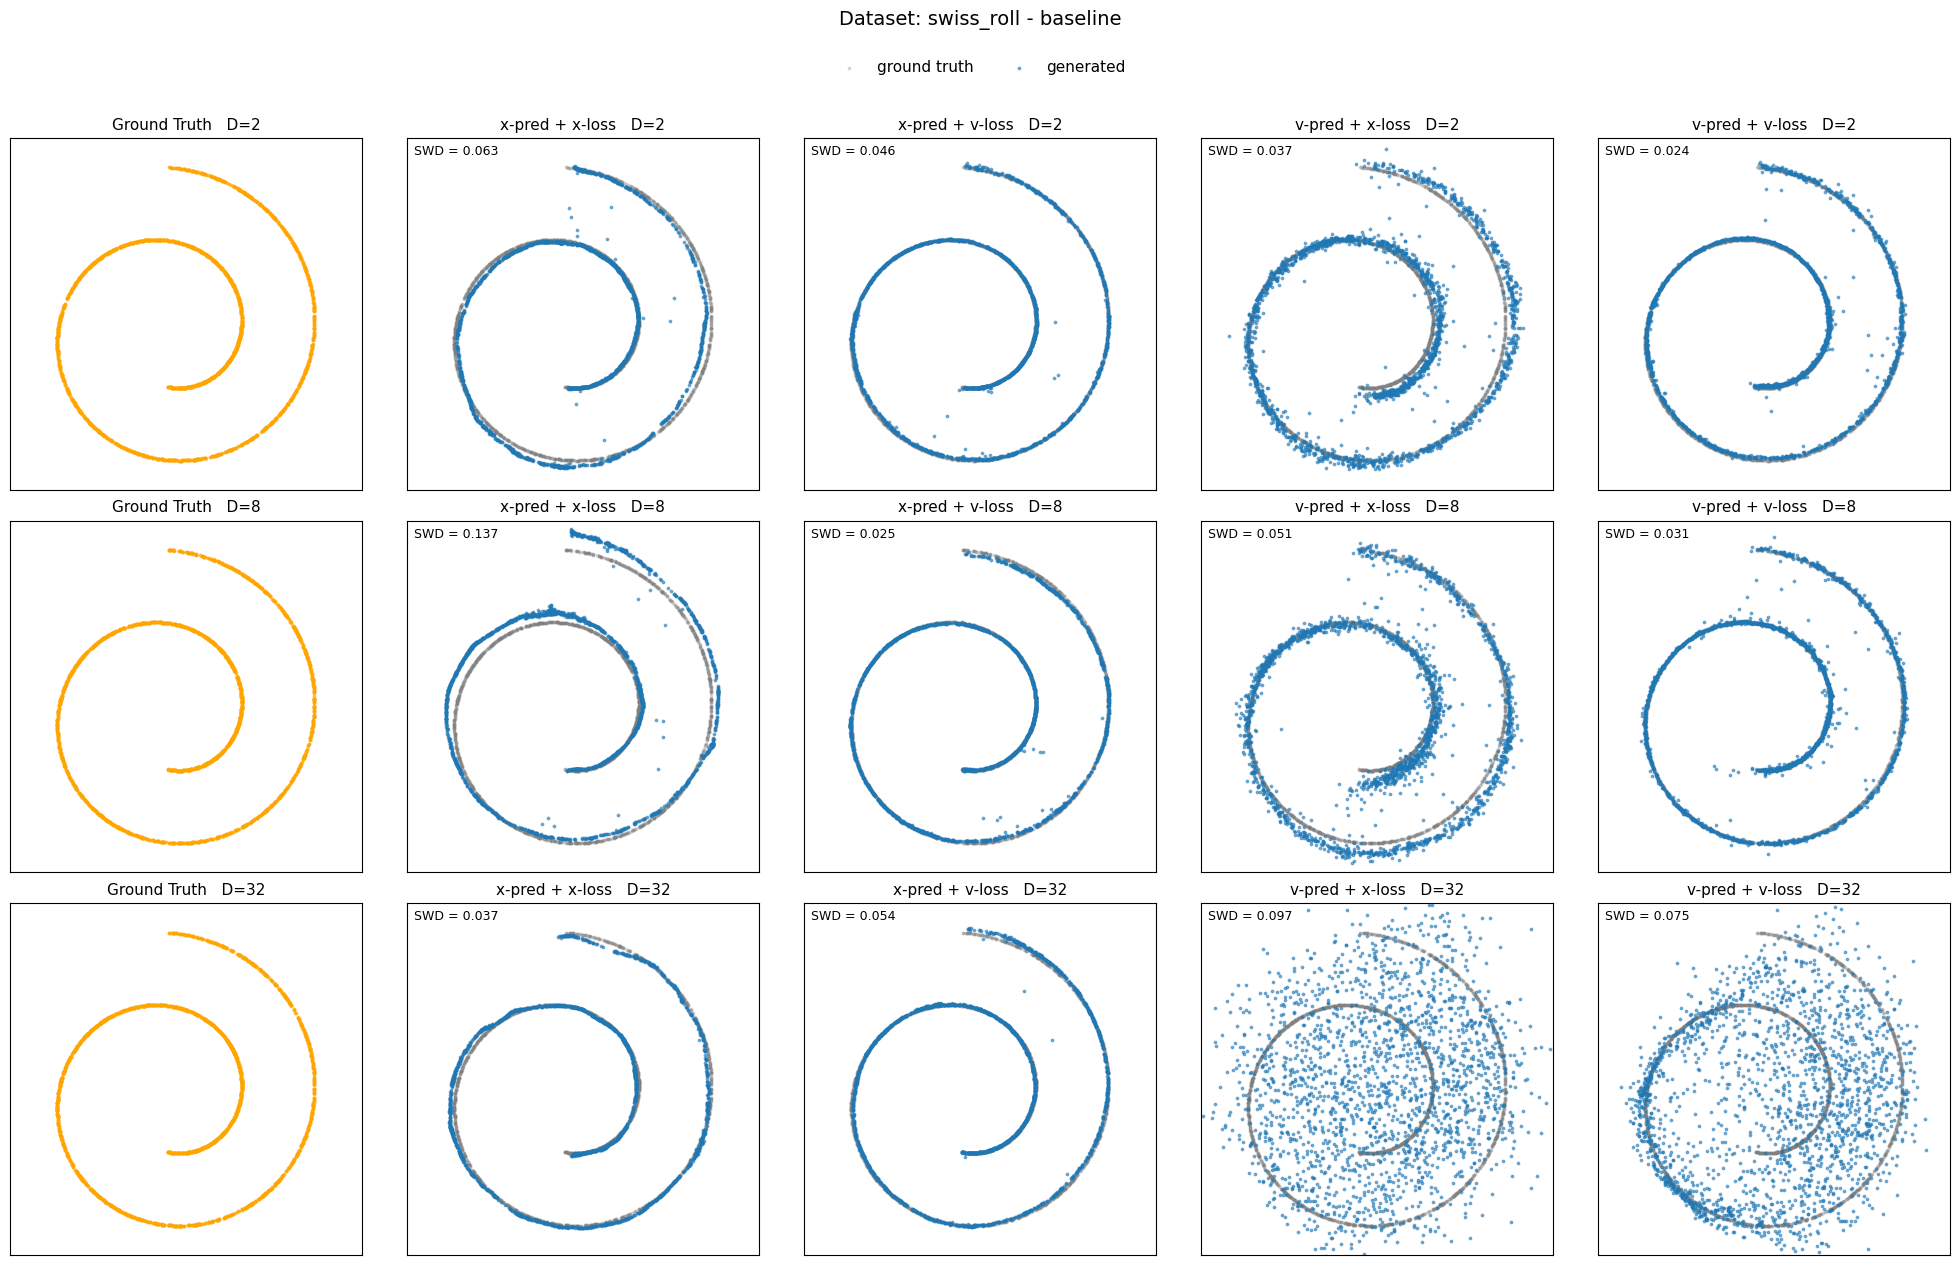

In [4]:
swds_baseline = plot_grid(
    DATASET, device,
    model_dir=MODEL_DIR, opt=False,
    title_suffix="baseline",
    save_name=f"{DATASET}_grid_baseline.png",
    hidden_dim=256,
)

## Improved (`opt001`)

`opt=True` draws training noise and the initial sampling latent in the intrinsic 2D subspace and lifts them through `P`, so $z_t$ stays on the same low-rank manifold the data lives on. Trains all 12 configs on `swiss_roll` and saves to `models/opt001/`. Re-runs are cached - delete a checkpoint to retrain.

In [ ]:
for D in DIMS:
    for pred, loss in PRED_LOSS:
        tag = model_tag(DATASET, D, pred, loss)
        path = OPT_DIR / f"{tag}.pt"
        if path.exists():
            print(f"[skip] {tag} already trained")
            continue
        print(f"[train] {tag}")
        train_one_config(DATASET, D, pred, loss, device,
                         model_dir=OPT_DIR, opt=True, hidden_dim=256)

In [ ]:
swds_opt = plot_grid(
    DATASET, device,
    model_dir=OPT_DIR, opt=True,
    title_suffix="opt001 (low-rank noise)",
    save_name=f"{DATASET}_grid_opt001.png",
    hidden_dim=256,
)

In [ ]:
# Side-by-side Density / Coverage table: baseline vs opt001.
# Higher is better for both. Density ≈ "fraction of gen samples on the real manifold"
# (fidelity); Coverage ≈ "fraction of real modes that gen reaches" (diversity).
header = (f"{'config':<22}{'D':>4}  "
          f"{'Dens b':>8}{'Dens o':>8}{'Δ Dens':>9}   "
          f"{'Cov b':>8}{'Cov o':>8}{'Δ Cov':>9}")
print(header)
print("-" * len(header))
for pred, loss in PRED_LOSS:
    for D in DIMS:
        bd, bc = swds_baseline[(pred, loss, D)]
        od, oc = swds_opt[(pred, loss, D)]
        print(f"{pred}-pred + {loss}-loss   {D:>4}  "
              f"{bd:>8.3f}{od:>8.3f}{od - bd:>+9.3f}   "
              f"{bc:>8.3f}{oc:>8.3f}{oc - bc:>+9.3f}")

## Improved (`opt002`)

Test across Hidden Layers

In [ ]:
# h=256 is already covered by opt001 — opt002 explores wider MLPs with the same opt=True.
H_TO_DIR = {
    512:  OPT2_H512_DIR,
    1024: OPT2_H1024_DIR,
}

In [ ]:
for h, model_dir in H_TO_DIR.items():
    for D in DIMS:
        for pred, loss in PRED_LOSS:
            tag = model_tag(DATASET, D, pred, loss)
            path = model_dir / f"{tag}.pt"
            if path.exists():
                print(f"[skip] h={h} {tag} already trained")
                continue
            print(f"[train] h={h} {tag}")
            train_one_config(DATASET, D, pred, loss, device,
                             model_dir=model_dir, opt=True, hidden_dim=h)

### Plot grids (opt002)

Same Part-2 layout as baseline / opt001, one per hidden width.

In [ ]:
swds_opt2_h512 = plot_grid(
    DATASET, device,
    model_dir=OPT2_H512_DIR, opt=True,
    title_suffix="opt002 (low-rank noise, h=512)",
    save_name=f"{DATASET}_grid_opt002_h512.png",
    hidden_dim=512,
)

In [ ]:
swds_opt2_h1024 = plot_grid(
    DATASET, device,
    model_dir=OPT2_H1024_DIR, opt=True,
    title_suffix="opt002 (low-rank noise, h=1024)",
    save_name=f"{DATASET}_grid_opt002_h1024.png",
    hidden_dim=1024,
)

## Aggregate results

Walks every stage in `STAGES`, gathers per-config stats (params, file size, train time, final loss,
loss-curve path) and writes them to `models/part3/results.json`. All downstream plots read from this
list — so once it's saved, you can restart the kernel and re-plot without rerunning training. Adding
a new stage = append to `STAGES` + re-run this cell.

Anything missing (e.g. older checkpoints with no `_meta.json`) shows up as `None` and is handled
gracefully by the plot/table cells below.

In [ ]:
def collect_stage(label, model_dir, hidden_dim, opt):
    rows = []
    for D in DIMS:
        for pred, loss in PRED_LOSS:
            tag = model_tag(DATASET, D, pred, loss)
            pt   = model_dir / f"{tag}.pt"
            meta = model_dir / f"{tag}_meta.json"
            lpath = model_dir / f"{tag}_losses.npy"
            if not pt.exists():
                continue

            row = {
                "stage": label, "hidden_dim": hidden_dim, "opt": opt,
                "D": D, "pred": pred, "loss": loss, "tag": tag,
                "checkpoint": str(pt),
                "file_size_bytes": pt.stat().st_size,
                "n_params": sum(p.numel() for p in JiM(hidden_dim=hidden_dim, D=D).parameters()),
                "train_time_s": None,
                "final_loss": None,
                "losses_path": str(lpath) if lpath.exists() else None,
            }
            if meta.exists():
                m = json.loads(meta.read_text())
                row["train_time_s"] = m.get("train_time_s")
            if lpath.exists():
                arr = np.load(lpath)
                row["final_loss"] = float(arr[-min(500, len(arr)):].mean())
            rows.append(row)
    return rows


results = []
for label, model_dir, hidden_dim, opt in STAGES:
    results.extend(collect_stage(label, model_dir, hidden_dim, opt))

RESULTS_PATH = PART3_RESULTS / "results.json"
RESULTS_PATH.write_text(json.dumps(results, indent=2))
print(f"saved {len(results)} rows -> {RESULTS_PATH}")

# Reload pattern (kernel-restart safe):
#   results = json.loads(Path("models/part3/results.json").read_text())

## Loss curves

Condensed: one line per stage = mean smoothed training loss across all 12 (D × pred/loss) configs.
Stages with no `_losses.npy` (e.g. older baseline / opt001 checkpoints) are skipped — delete a `.pt`
and re-run that stage's training cell to populate.

In [ ]:
def smooth(x, window=200):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def stage_mean_loss(rows):
    arrs = [np.load(r["losses_path"]) for r in rows if r["losses_path"]]
    if not arrs:
        return None
    n = min(len(a) for a in arrs)
    return np.stack([a[:n] for a in arrs]).mean(axis=0), len(arrs)


by_stage = {}
for r in results:
    by_stage.setdefault(r["stage"], []).append(r)

fig, ax = plt.subplots(figsize=(10, 6))
plotted = False
for label, _md, _h, _o in STAGES:
    rows = by_stage.get(label, [])
    out = stage_mean_loss(rows)
    if out is None:
        continue
    mean, n = out
    ax.plot(smooth(mean), label=f"{label} (n={n})", linewidth=1.6)
    plotted = True

ax.set_xlabel("Training step")
ax.set_ylabel("Mean training loss across configs (smoothed)")
ax.set_yscale("log")
ax.set_title(f"Training loss across stages — {DATASET}")
ax.grid(True, alpha=0.3)
if plotted:
    ax.legend()
else:
    ax.text(0.5, 0.5, "no loss data\n(retrain at least one stage to populate)",
            ha="center", va="center", transform=ax.transAxes, fontsize=11)

fig.tight_layout()
fig.savefig(FIG_DIR / "loss_curves_stages.png", dpi=150, bbox_inches="tight")
plt.show()

## Performance — params, size, training time

Per-stage roll-up (params per `D`, total checkpoint size, total wall-clock training time) plus the
full per-config table. `time data k/N` shows how many of the N checkpoints in that stage have a
recorded `train_time_s` — checkpoints from before the metadata change show `—`.

The per-config dataframe-style print is the source for any custom analysis (e.g. averaging time
across the best-performing configs, plotting cost vs hidden width, etc.). Everything you need is
already in `results` / `models/part3/results.json`.

In [ ]:
def fmt_time(s):
    if s is None:
        return "—"
    m, s = divmod(int(s), 60)
    return f"{m}m {s:>2}s"


def fmt_size(b):
    return f"{b / 1e6:.2f} MB"


def fmt_loss(x):
    return f"{x:.4f}" if x is not None else "—"


# --- per-stage summary -------------------------------------------------------
print("Stage summary")
print(f"{'stage':<16}{'h':>6}{'cfgs':>6}{'params D=2/8/32':>26}{'total size':>14}{'total time':>14}{'time data':>12}")
print("-" * 96)
for label, _md, hidden_dim, _opt in STAGES:
    rows = by_stage.get(label, [])
    if not rows:
        print(f"{label:<16}{hidden_dim:>6}{0:>6}{'—':>26}{'—':>14}{'—':>14}{'0/0':>12}")
        continue
    p_by_d = {r["D"]: r["n_params"] for r in rows}
    p_str = "/".join(f"{p_by_d.get(D, 0):>7}" for D in DIMS)
    total_size = sum(r["file_size_bytes"] for r in rows)
    times = [r["train_time_s"] for r in rows if r["train_time_s"] is not None]
    total_t = sum(times) if times else None
    cov = f"{len(times)}/{len(rows)}"
    print(f"{label:<16}{hidden_dim:>6}{len(rows):>6}{p_str:>26}{fmt_size(total_size):>14}{fmt_time(total_t):>14}{cov:>12}")

# --- per-config table --------------------------------------------------------
print()
print("Per-config detail")
print(f"{'stage':<16}{'h':>6}{'D':>4}{'pred':>6}{'loss':>6}{'params':>10}{'size':>10}{'time':>10}{'final loss':>14}")
print("-" * 86)
for r in results:
    params  = f"{r['n_params']}"
    size    = fmt_size(r['file_size_bytes'])
    t       = fmt_time(r['train_time_s'])
    fl      = fmt_loss(r['final_loss'])
    print(f"{r['stage']:<16}{r['hidden_dim']:>6}{r['D']:>4}{r['pred']:>6}{r['loss']:>6}"
          f"{params:>10}{size:>10}{t:>10}{fl:>14}")